In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer,confusion_matrix,ConfusionMatrixDisplay, roc_auc_score

import xgboost as xgb
import lightgbm as lgb

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import itertools
from sklearn.ensemble import ExtraTreesClassifier
import shap
import pycountry
import re


from sklearn.preprocessing import StandardScaler, RobustScaler

from tsfresh.utilities.dataframe_functions import roll_time_series
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters # trop gourmand
from tsfresh.feature_extraction import MinimalFCParameters # idem
import time

from sklearn.decomposition import PCA


# Analyse complète du dataset dense : de la préparation des données à l'interprétation des modèles

In [2]:
# random seed
random_seed = 42

In [3]:
dataset1 = pd.read_csv('dataset.csv') 

dataset1.drop(columns=("Unnamed: 0"),inplace=True)

In [5]:
correspondanceIndicateurs = pd.read_csv('correspondance_indicateurs.csv') # pour l'explicabilité

## Suppression des features avec plus de 25% de missing values pour au moins un pays + ajout de flag: was_interpolated

In [6]:
indicator_cols = dataset1.columns.difference(['REF_AREA', 'TIME_PERIOD','war'])


#matrice des valeurs manquantes par pays et indicateur

missing_matrix = (
    dataset1.groupby('REF_AREA')[indicator_cols]
    .apply(lambda g: g.isna().mean())
)
# On supprime les indicateurs avec trop de valeurs manquantes par pays 
missingMatrix2 = missing_matrix.copy()
for i in missingMatrix2.columns:
    if missingMatrix2[i].max()>0.25:
        missingMatrix2.drop(i,axis=1,inplace=True)


### Code pour ne garder que les colonnes présentes dans missingMatrix2

colKeep = [ "REF_AREA","TIME_PERIOD", "war"]

cols_to_keep = list(missingMatrix2.columns) + colKeep
cols_to_keep = list(dict.fromkeys(cols_to_keep))  

dataset1 = dataset1[cols_to_keep]




In [7]:
### DATAFRAME AVEC INDICATEURS + FLAG : was_interpolated

df_flagInterpolated = dataset1.copy()
cols = [c for c in df_flagInterpolated.columns if c not in ['REF_AREA', 'TIME_PERIOD', 'war']]

for i in cols:
    df_flagInterpolated[f"{i}_was_interpolated"] = dataset1[i].isna()

dataset1 = df_flagInterpolated

# On remet REF_AREA et TIME_PERIOD en début de dataframe
cols = ["REF_AREA", "TIME_PERIOD"]  
new_order = cols + [c for c in dataset1.columns if c not in cols]

dataset1 = dataset1[new_order]


In [8]:
# conversion du flag en int

## On repasse le type des colonnes 'was_interpolated' en int au lieu de bool

cols_to_convert = [
    c for c in dataset1.columns 
    if "_was_interpolated" in c
]

for col in cols_to_convert:
    dataset1[col] = dataset1[col].astype(int)

## on doit décaler de -1 la variable à prédire y (war)
- pourquoi ? : les indicateurs pour un pays/année sont récupérés en fin d'année et résume l'année qui vient d'avoir lieu donc prédire l'état de conflit avec ces indicateurs pour cette même année ne fait pas trop sens. On va donc prédire pour les indicateurs à l'année t, le conflit pour l'année t+1


In [9]:

def shiftWar(df):
    """
    décale la variable cible (war) de 1 en arrière
    la ligne pour un pays k et une année n va avoir comme variable cible war mais pour l'année n+1

    Returns:
        shifted (pd.Dataframe) : corréspond au df d'entrée avec la variable cible décalé de 1 (changement de nom de la variable cible : war_nextYear)
    """
    df_shifted = []

    
    for country, group in df.groupby("REF_AREA"):
        g = group.copy()  # correspond au sous-dataframe de chaque pays
        g['war_nextYear'] = g['war'].shift(-1)# décaler les valeurs de war de 1 en arrière
        g = g[:-1]  # supprimer dernière année qui n'a pas de target
        df_shifted.append(g)
    # Concaténer en préservant l'ordre
    shifted = pd.concat(df_shifted, ignore_index=True)
    shifted["war_nextYear"]  = shifted['war_nextYear'].astype(int) # remettre la valeur de war_nextYear en entier
    shifted.drop("war",axis=1,inplace=True)
    return shifted


dataset1 = shiftWar(dataset1)


## Split train test

In [11]:
# solution au manque de généralisation dû au split par pays
# split temporelle

dfPreprocess = dataset1.copy()

features = dfPreprocess.columns.tolist()




test = dfPreprocess[dfPreprocess['TIME_PERIOD']>2011]
train_tot  = dfPreprocess[dfPreprocess['TIME_PERIOD']<=2011] # jeu de train+validation 
train = train_tot[train_tot['TIME_PERIOD']<=2001] # jeu de train uniquement pour la validation
validation  = train_tot[train_tot['TIME_PERIOD']>2001] # jeu de validation




print("train_tot :", train_tot["war_nextYear"].mean())
print("train  :", train["war_nextYear"].mean())
print("val    :", validation["war_nextYear"].mean())
print("test   :", test["war_nextYear"].mean())

# répartition des classes respectée à travers des set

train_tot : 0.41524846834581347
train  : 0.4112937210282343
val    : 0.431858407079646
test   : 0.38421828908554573


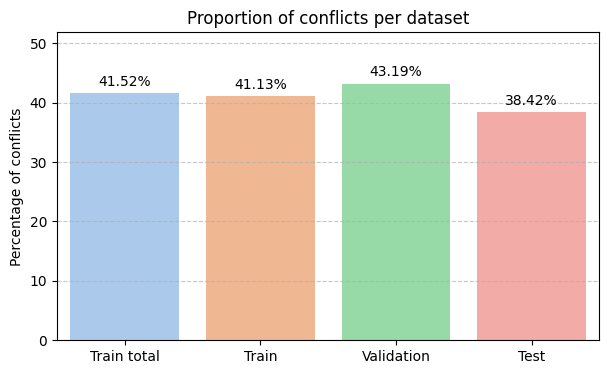

In [12]:
## Code pour afficher la distribution des classes (war) dans chaque set
# Données
data = pd.DataFrame({
    "Set": ["Train total", "Train", "Validation", "Test"],
    "Proportion de conflit (%)": [
        train_tot["war_nextYear"].mean() * 100,
        train["war_nextYear"].mean() * 100,
        validation["war_nextYear"].mean() * 100,
        test["war_nextYear"].mean() * 100,
    ]
})

plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=data,
    x="Set",
    y="Proportion de conflit (%)",
    hue="Set",
    palette="pastel",
    legend=False
)

# labels sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Proportion of conflicts per dataset")
plt.ylabel("Percentage of conflicts")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0, data["Proportion de conflit (%)"].max() * 1.2)

plt.savefig("results/repartitionClasse_split.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpolation etc..
- Méthode Time pour la globalité des données 
- et pour le reste méthode linéar

In [13]:

def temporal_interpolation_per_country(df):
    """
    Applique une interpolation temporelle par pays, pour éviter tout data leakage, 
    on process sur le dataset de train et de test séparément
    """
    dfInterpole = df.copy()

    
    # Conversion TIME_PERIOD en Datetime pour pouvoir utiliser la méthode "time" de interpolate
    dfInterpole["TIME_PERIOD"] = pd.to_datetime(dfInterpole["TIME_PERIOD"], format='%Y')
    # on le met en index
    dfInterpole = dfInterpole.set_index("TIME_PERIOD")
    # Colonnes à interpoler
    col_to_interp = [c for c in dfInterpole.columns if c not in ["REF_AREA",'war_nextYear'] and "_was_interpolated" not in c]
    print(f"avant interpolation : {dfInterpole.isna().sum().sum()}")
    #  Interpolation temporelle 
    interpolated = (
        dfInterpole.groupby("REF_AREA")[col_to_interp]
        .apply(lambda g: g.sort_index().interpolate(method="time", limit_direction='both', limit=5))
    )
    # ça créer des multiindex, donc on retirer REF_AREA
    dfInterpole[col_to_interp] = interpolated.droplevel(0)
    print("Après time :", dfInterpole[col_to_interp].isna().sum().sum())
    
    # Dans le cas où la méthode time n'a pas pu tout interpoler (pas assez de point, des points isolés..)
    interpolated = (
        dfInterpole.groupby("REF_AREA")[col_to_interp]
        .apply(lambda g: g.sort_index().interpolate(method="linear", limit_direction='both'))
    )
    dfInterpole[col_to_interp] = interpolated.droplevel(0)
    print("Après linear :", dfInterpole[col_to_interp].isna().sum().sum())
    
 
    # on remet TIME_PERIOD en colonne après le traintement
    dfInterpole = dfInterpole.reset_index()
    return dfInterpole
    


print("interpolation train")    
train_interpolated = temporal_interpolation_per_country(train)

print("interpolation train_tot")    
train_tot_interpolated = temporal_interpolation_per_country(train_tot)

print("interpolation validation")
validation_interpolated  = temporal_interpolation_per_country(validation)

print("interpolation test")
test_interpolated  = temporal_interpolation_per_country(test)




interpolation train
avant interpolation : 1368
Après time : 565
Après linear : 0
interpolation train_tot
avant interpolation : 1368
Après time : 565
Après linear : 0
interpolation validation
avant interpolation : 0
Après time : 0
Après linear : 0
interpolation test
avant interpolation : 245
Après time : 0
Après linear : 0


## feature lag

In [14]:
# feature lag

def create_lag_features(df,isValidation = False):
    """
    Crée des lags n-1, n-2, n-3 pour chaque feature (sauf REF_AREA, TIME_PERIOD, war_nextYear)
    """
    dfs = []
    
    for country, group in df.groupby("REF_AREA"):
        group = group.sort_values("TIME_PERIOD").copy()
        
        cols_to_lag = [
            col for col in group.columns
            if col not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"]
        ]
        
        lag_frames = {}
        for lag in [1, 2, 3]:
            lag_df = group[cols_to_lag].shift(lag)
            lag_df.columns = [f"{c}_lag{lag}" for c in cols_to_lag]
            lag_frames[lag] = lag_df
        
        group = pd.concat([group] + list(lag_frames.values()), axis=1)
        group = group.iloc[3:]  # Supprimer les 3 premières lignes avec NaN dans les lags
        
        dfs.append(group)
    
    dataset_lagged = pd.concat(dfs, ignore_index=True)
    
    # Supprimer les années 1960, 1961, 1962 (NaN dans les lags)
    for annee in [1960, 1961, 1962]:
        dataset_lagged = dataset_lagged[dataset_lagged["TIME_PERIOD"] != annee]
    for annee in [2012, 2013, 2014]:
        dataset_lagged.drop(dataset_lagged.loc[dataset_lagged["TIME_PERIOD"] == annee].index, inplace=True)
        
    if isValidation:
        for annee in [2002, 2003, 2004]:
            dataset_lagged.drop(dataset_lagged.loc[dataset_lagged["TIME_PERIOD"] == annee].index, inplace=True)
    
    return dataset_lagged

# Appliquer après interpolation, avant scaling
train_interpolatedLag = create_lag_features(train_interpolated)
train_tot_interpolatedLag = create_lag_features(train_tot_interpolated)
validation_interpolatedLag = create_lag_features(validation_interpolated, isValidation=True)
test_interpolatedLag = create_lag_features(test_interpolated)

## Scaling

### RobustScaler fit sur train et transform sur train et test

In [15]:

# je veux fit sur train et transform sur train et test


def StandardisationRobust(train, test, cols_to_scale):
    """
    Scaling des données après split en train/test
    Méthode utilisée : RobustScaler -> lorsque les variables ont beaucoup d'outliers : éco...
    Stratégie : on fit sur X_train et on transform sur X_train et X_test

    Parameters :
        train (pd.Dataframe()): dataframe des données d'entrainement
        test (pd.Dataframe()): dataframe des données de test
        cols_to_scale (list(String)) : liste des noms de colonnes à scaler 
    Returns :
        train_scaled (pd.Dataframe()) : dataframe des données d'entrainement scalé
        test_scaled (pd.Dataframe()) : dataframe des données de test scalé
    """
    train_scaled = train.copy()
    test_scaled = test.copy()
    
    scaler = RobustScaler()
    scaler.fit(train_scaled[cols_to_scale])

    train_scaled[cols_to_scale] = scaler.transform(train_scaled[cols_to_scale]) 
    test_scaled[cols_to_scale] = scaler.transform(test_scaled[cols_to_scale]) 
    
    return train_scaled, test_scaled
    
    

cols_to_scale = [
    c for c in train_interpolated.columns 
    if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"] and "_was_interpolated" not in c
]

train_tot_scaled, test_scaled = StandardisationRobust(train_tot_interpolated,test_interpolated, cols_to_scale)
train_scaled, validation_scaled = StandardisationRobust(train_interpolated,validation_interpolated, cols_to_scale)

# avec lag


cols_to_scale_lag = [
    c for c in train_interpolatedLag.columns 
    if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"] 
    and "_was_interpolated" not in c
]

train_tot_scaledLag, test_scaledLag = StandardisationRobust(train_tot_interpolatedLag,test_interpolatedLag, cols_to_scale_lag)
train_scaledLag, validation_scaledLag = StandardisationRobust(train_interpolatedLag,validation_interpolatedLag, cols_to_scale_lag)


### StandardScaler pour appliquer une PCA

In [16]:
# TEST de standardisation plus classique


def StandardisationStandard(train, test, cols_to_scale):
    """
    Scaling des données après split en train/test
    Méthode utilisée : transformation logarithmique (pour applatir) + StandardScaler
    Stratégie : on fit sur X_train et on transform sur X_train et X_test

    Parameters :
        X_train (pd.Dataframe()): dataframe des données d'entrainement
        X_test (pd.Dataframe()): dataframe des données de test
        cols_to_scale (list(String)) : liste des noms de colonnes à scaler 
    Returns :
        X_train_scaled (pd.Dataframe()) : dataframe des données d'entrainement scalé
        X_test_scaled (pd.Dataframe()) : dataframe des données de test scalé
    """
    train_scaled = train.copy()
    test_scaled = test.copy()

    train_log = train.copy()
    #train_log[cols_to_scale] = np.log1p(train_log[cols_to_scale])

    test_log = test.copy()
    #test_log[cols_to_scale] = np.log1p(test_log[cols_to_scale])
    
    scaler = StandardScaler()
    scaler.fit(train_log[cols_to_scale])

    train_scaled[cols_to_scale] = scaler.transform(train_log[cols_to_scale]) 
    test_scaled[cols_to_scale] = scaler.transform(test_log[cols_to_scale]) 
    
    return train_scaled, test_scaled
    
    

cols_to_scale = [
    c for c in train_interpolated.columns 
    if c not in ["REF_AREA", "TIME_PERIOD", "war_nextYear"] and "_was_interpolated" not in c
]


# avec lag

train_tot_scaledStandardLag, test_scaledStandardLag = StandardisationStandard(train_tot_interpolatedLag,test_interpolatedLag, cols_to_scale_lag)
train_scaledStandardLag, validation_scaledStandardLag = StandardisationStandard(train_interpolatedLag,validation_interpolatedLag, cols_to_scale_lag)

## Partie création de rolling window

In [19]:
def calcul_rolling_stats(df_input, cols_to_use):
    """
    Applique le rolling window et calcule les stats pour un dataframe donné
    Pour chaque colonne de cols_to_use : 
        -applique un rolling window sur les séries temporelles par pays
        -calcule des statistique (mean,max...)
        -reconstruit un Df avec les features de créées
        -Réassocie REF_AREA et TIME_PERIOD pour merge avec les données d'origines
        -supprimes les lignes contenant des NaN
    """
    print(f"\n Traitement ")
    
    # Préparation pour tsfresh
    df_for_rolling = df_input[['REF_AREA', 'TIME_PERIOD'] + cols_to_use].copy()
    
    df_rolled = roll_time_series(
        df_for_rolling,
        column_id='REF_AREA',
        column_sort='TIME_PERIOD',
        max_timeshift=3,
        min_timeshift=1
    )
    
    # On enlève REF_AREA car l'id du pays est maintenant dans 'id' créé par tsfresh 
    df_rolled = df_rolled.drop('REF_AREA', axis=1)
    grouped = df_rolled.groupby('id')
    
    print(f"Calcul des stats")
    
    features_list = []
    for col in cols_to_use:
        series = grouped[col] # On récupère la série une seule fois par colonne
        
        features_list.extend([
            series.mean().rename(f'{col}_mean'),
            series.std().rename(f'{col}_std'),
            series.min().rename(f'{col}_min'),
            series.max().rename(f'{col}_max'),
            series.median().rename(f'{col}_median'),
            (series.max() - series.min()).rename(f'{col}_range'),
            series.quantile(0.25).rename(f'{col}_q25'),
            series.quantile(0.75).rename(f'{col}_q75')
        ])

    # Reconstruction du DataFrame
    df_features = pd.concat(features_list, axis=1)
    
    # on recupère REF_AREA et TIME_PERIOD depuis l'id (de tsfresh)
    df_features = df_features.reset_index()
    df_features['REF_AREA'] = df_features['id'].apply(lambda x: x[0])
    df_features['TIME_PERIOD'] = pd.to_datetime(df_features['id'].apply(lambda x: x[1]))
    
    # Merge avec les données d'origine
    df_final = df_input.merge(
        df_features.drop('id', axis=1),
        on=['REF_AREA', 'TIME_PERIOD'],
        how='left'
    )
    
    # Gestion des NaN (cas où aucune feature n'a pu être créées)
    n_nan = df_final.isna().any(axis=1).sum()
    if n_nan > 0:
        print(f"Lignes supprimées (NaN): {n_nan} ({n_nan/len(df_final):.1%})")
        
    return df_final.dropna()


#  fct principale
def createStatsFeatures(train_scaled, test_scaled):
    debut = time.time()
    
    
    cols_to_use = [
        c for c in train_scaled.columns 
        if c not in ['REF_AREA','TIME_PERIOD','war_nextYear'] 
        and "_was_interpolated" not in c
    ]
    print(f"Nombre de colonnes utilisées {len(cols_to_use)}")

    # Appel de la fonction pour Train
    train_final = calcul_rolling_stats(train_scaled, cols_to_use)

    # Appel de la fonction pour Test
    test_final = calcul_rolling_stats(test_scaled, cols_to_use)

    fin = time.time()
    print(f"FIN")
    print(f"Temps d'exec: {(fin-debut):.2f} s")
    print(f"Shape Train: {train_final.shape}")
    print(f"Shape Test : {test_final.shape}")
    
    return train_final, test_final

### création de la rolling window mis en commentaire étant donné qu'on l'utilise plus et que c'est assez long

In [20]:
#train_tot_final, test_final = createStatsFeatures(train_tot_scaled,test_scaled)
#train_final, validation_final =createStatsFeatures(train_scaled,validation_scaled)

In [21]:
#train_tot_finalStandard, test_finalStandard = createStatsFeatures(train_tot_scaledStandard,test_scaledStandard)
#train_finalStandard, validation_finalStandard = createStatsFeatures(train_scaledStandard,validation_scaledStandard)

## Séparation en X / y

In [22]:

#séparer X/y robust + lag

X_trainScaledLag = train_scaledLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_trainScaledLag = train_scaledLag['war_nextYear']

X_validationScaledLag = validation_scaledLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_validationScaledLag = validation_scaledLag['war_nextYear']


X_train_totScaledLag = train_tot_scaledLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_train_totScaledLag = train_tot_scaledLag['war_nextYear']

X_testScaledLag = test_scaledLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_testScaledLag = test_scaledLag['war_nextYear']


In [23]:

# avec lag sans (rolling window + stats)

X_trainLag = train_scaledStandardLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_trainLag = train_scaledStandardLag['war_nextYear']

X_validationLag = validation_scaledStandardLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_validationLag = validation_scaledStandardLag['war_nextYear']


X_trainLag_tot = train_tot_scaledStandardLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_trainLag_tot = train_tot_scaledStandardLag['war_nextYear']

X_testLag = test_scaledStandardLag.drop(['war_nextYear', 'REF_AREA', 'TIME_PERIOD'], axis=1)
y_testLag = test_scaledStandardLag['war_nextYear']


X_train shape: (4746, 166)
y_train shape: (4746,)


## PCA + suppression des flags - on applique la PCA uniquement sur les dataset scalé avec le standardScaler 

In [24]:

def applyPCA(X_train, X_test, cols_to_drop, n_components=0.95,verbose= False):
    """
    Applique la PCA, visualise les résultats et renvoie les données transformées
    
    Args:
        n_components: float (0.95) pour garder 95% de variance
    Returns:
        df_train_pca (Dataframe) données d'entrainement transformées
        df_test_pca (Dataframe) données de test transformées
        pca objet PCA entrainé sur les données
    """
    print("DEBUT PCA")
    
    # On retire les colonnes spécifiées 
    X_train_clean = X_train.drop(columns=cols_to_drop)
    X_test_clean = X_test.drop(columns=cols_to_drop)

    # Calcul PCA
    pca = PCA(n_components=n_components, random_state=random_seed)
    
    X_train_pca = pca.fit_transform(X_train_clean)
    X_test_pca = pca.transform(X_test_clean)
    
    # Création des DataFrames clean (on garde l'index d'origine)
    pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
    
    df_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    df_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

    if verbose:
        print(f"Dimensions originales : {X_train_clean.shape}")
        print(f"Dimensions PCA : {df_train_pca.shape} (pour {n_components*100}% de variance)")
        print(f"Variance expliquée : {pca.explained_variance_ratio_.sum():.4f}")

        # visualisation
    
        # A-Variance Cumulée
        plt.figure(figsize=(10, 4))
        cumulative_variance = pca.explained_variance_ratio_.cumsum()
        plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
        plt.axhline(y=0.95, color='r', linestyle='-', alpha=0.5, label='95% Seuil')
        plt.title('PCA - Variance Expliquée Cumulée')
        plt.xlabel('Nombre de Composantes')
        plt.ylabel('Variance')
        plt.grid(True)
        plt.legend()
        plt.show()

    # On regarde les loadings (poids) des variables sur les composantes
    loadings = pd.DataFrame(
        pca.components_.T,
        index=X_train_clean.columns,
        columns=pca_cols
    )
    
    # On sélectionne les 20 variables qui pèsent le plus lourd au total
    top_vars = loadings.abs().sum(axis=1).sort_values(ascending=False).head(20).index
    
    # On affiche la Heatmap limité aux 5 premières PC 
    cols_to_show = pca_cols[:10] if len(pca_cols) > 10 else pca_cols
    
    if verbose:
        plt.figure(figsize=(12, 6))
        sns.heatmap(loadings.loc[top_vars, cols_to_show], cmap="coolwarm", center=0)
        plt.title("PCA - Top 20 Variables contribuantes (Loadings)")
        plt.show()

    return df_train_pca, df_test_pca, pca


# colonnes à exclure
cols_not_pca = [c for c in train_interpolated.columns if "_was_interpolated" in c]



DEBUT PCA
Dimensions originales : (5537, 581)
Dimensions PCA        : (5537, 16) (pour 95.0% de variance)
Variance expliquée    : 0.9524


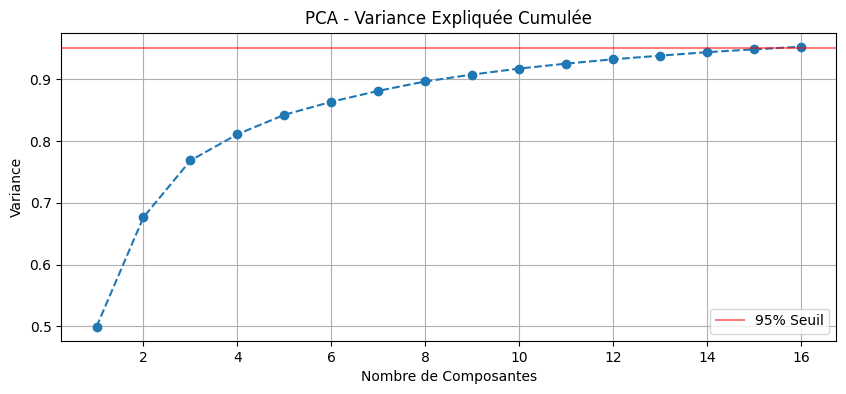

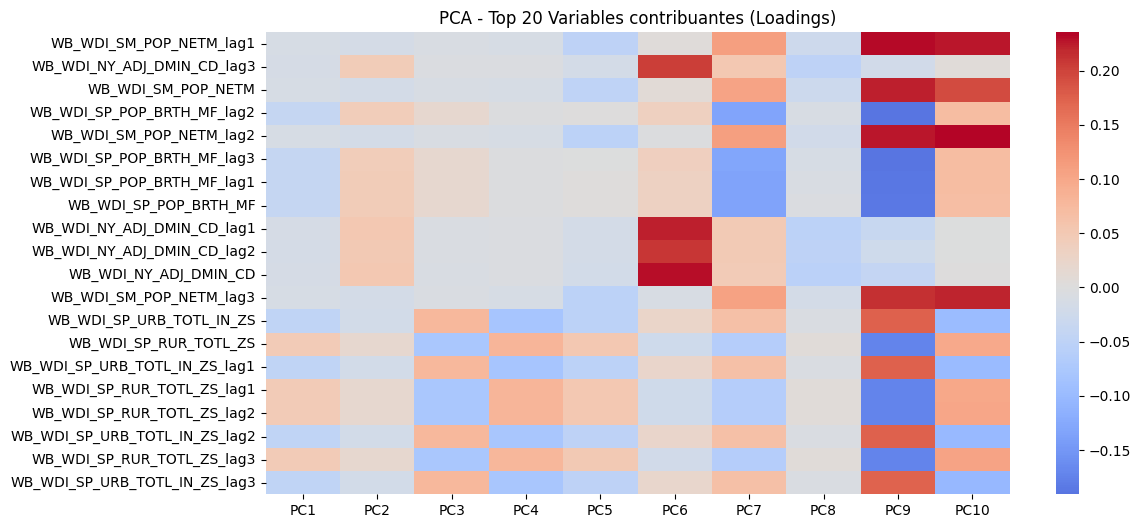

DEBUT PCA
Dimensions originales : (4407, 581)
Dimensions PCA        : (4407, 17) (pour 95.0% de variance)
Variance expliquée    : 0.9516


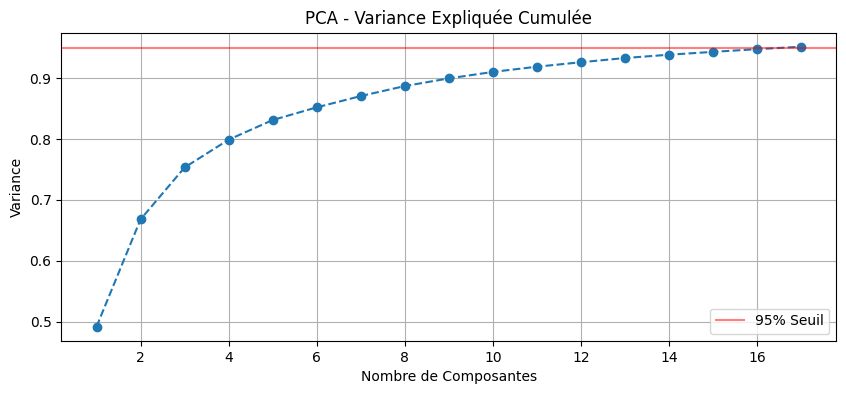

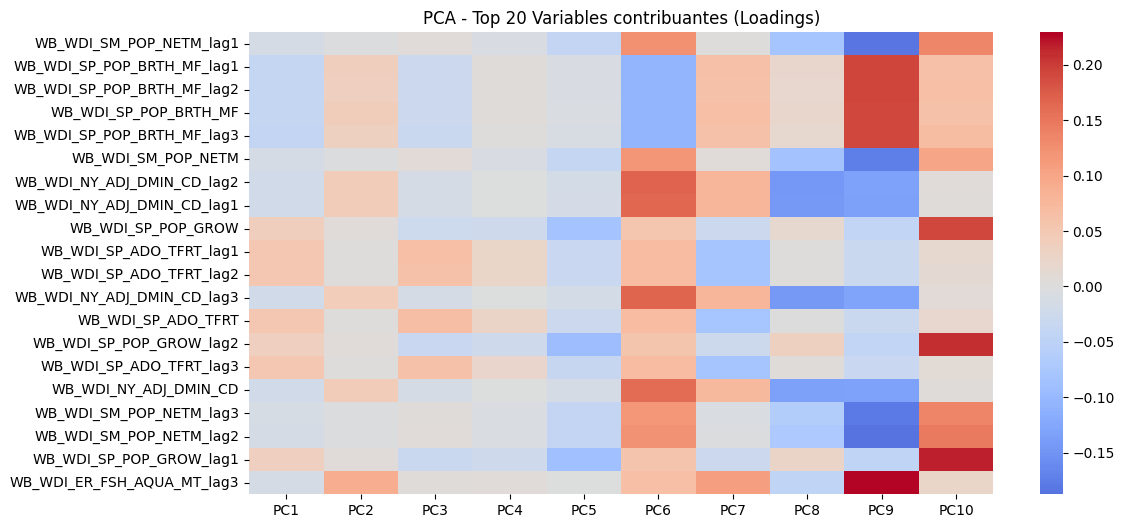

In [28]:
# application PCA pour données lag standardisée
X_train_tot_pcaLag, X_test_pcaLag, pca_modelLag = applyPCA(
    X_trainLag_tot, 
    X_testLag, 
    cols_to_drop=cols_not_pca,
    n_components=0.95,
    verbose=True
)


X_train_pcaLag, X_validation_pcaLag, pca_modelLag = applyPCA(
    X_trainLag, 
    X_validationLag, 
    cols_to_drop=cols_not_pca,
    n_components=0.95,
    verbose=True
) 

## Train  + evaluation


In [57]:
def train_and_evaluate(X_train, y_train, X_val, y_val, model, model_name,verbose = True):
    """
    Entraine un modèle sur un jeu de train et évalue sur un jeu de validation.
    
    params:
        X_train, y_train: données d'entraînement
        X_val, y_val: données de validation / test
        model: modèle (XGBoost, CatBoost, SVM, etc...)
        model_name: str, nom du modèle pour affichage
    Returns:
        dictionnaire de metrics
    """
    
    
    # Entrainement
    model.fit(X_train, y_train)
    
    # Prédiction
    y_pred_val = model.predict(X_val)
    y_pred_train = model.predict(X_train)
    
    # Calcul métriques
    metrics = {
        "accuracy": accuracy_score(y_val, y_pred_val),
        "precision": precision_score(y_val, y_pred_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_val, zero_division=0),
        "ROC-AUC" : roc_auc_score(y_val, y_pred_val),
        "f1": f1_score(y_val, y_pred_val, zero_division=0),
        "f1_train": f1_score(y_train, y_pred_train, zero_division=0)
    }
    
    if verbose:
        for k, v in metrics.items():
            print(f"{k:<12}: {v:.4f}")
        print(f"Overfitting (F1 train - F1 val): {metrics['f1_train'] - metrics['f1']:.4f}")
        
    return metrics

## sélection d'hyperparametres et de modèle
### gridSearch allégé

In [59]:

def manual_grid_search(model_class,param_grid,X_train, y_train,X_val, y_val,model_name,fixed_params=None):
    """
    Grid search simplifié manuel
    Args:
        model_class : classe du modèle (catboost,XGBoost,...)
        param_grid  : dict des paramètres à tester
        fixed_params: dict des paramètres fixes (random_state, class_weight, etc.)
    returns:
        DataFrame avec les métriques
    """

    if fixed_params is None:
        fixed_params = {}

    results = []
    # itère sur toutes les combinaisons de params possible
    for params in itertools.product(*param_grid.values()):
        param_dict = dict(zip(param_grid.keys(), params)) # dict param->valeur pour la combinaison en cours


        model = model_class(**param_dict, **fixed_params)

        metrics = train_and_evaluate(
            X_train, y_train,
            X_val, y_val,
            model,
            model_name,
            verbose=False
        )

        results.append({
            "model": model_name,
            **param_dict,
            **metrics,
            "f1_gap": metrics["f1_train"] - metrics["f1"] # calcule le gap F1 entre train et test
        })

    return pd.DataFrame(results).sort_values(
        by="f1", ascending=False
    )


### applyGridSearch : fonction pour appliquer le gridSearch sur les modèles

In [93]:
def applyGridSearch(X_train,y_train,X_test,y_test, doSvm = True):
    """
    pour un même jeu de données d'entrainement et de test, on applique un gridsearch avec différent modèles fixés
    
    """
    if doSvm:
        ## SVM
        print("### SVM ###")
        svm_grid = {
            "C": [0.1, 1, 10],
            "gamma": ["scale", 0.01, 0.1],
            "kernel": ["rbf"]
        }
        
        svm_fixed = {
            "class_weight": "balanced",
            "random_state": random_seed
        }
        
        df_svm = manual_grid_search(
            model_class=SVC,
            param_grid=svm_grid,
            fixed_params=svm_fixed,
            X_train=X_train,
            y_train=y_train,
            X_val=X_test,
            y_val=y_test,
            model_name="SVM"
        )
            
    # catboost
    
    print("### catboost ###")
    cat_grid = {
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05],
        "l2_leaf_reg": [1, 3, 5]
    }
    
    cat_fixed = {
        "iterations": 500,
        "loss_function": "Logloss",
        "verbose": 0,
        "random_seed": random_seed,
        "auto_class_weights":"Balanced"
    }
    
    df_cat = manual_grid_search(
        model_class=CatBoostClassifier,
        param_grid=cat_grid,
        fixed_params=cat_fixed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        model_name="CatBoost"
    )
        
    
    # MLP
    print("### MLP ###")
    mlp_grid = {
        "hidden_layer_sizes": [(50,), (100,), (50,50)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.001]  # L2
    }
    
    mlp_fixed = {
        "max_iter": 1000,
        "random_state": random_seed
    }
    
    df_mlp = manual_grid_search(
        model_class=MLPClassifier,
        param_grid=mlp_grid,
        fixed_params=mlp_fixed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        model_name="MLP"
    )
    
    
    # Xgboost
    print("### Xgboost ###")
    
    xgb_grid = {
        "max_depth": [3, 4, 5],
        "learning_rate": [0.05, 0.1],
        "n_estimators": [100, 200, 300]
    }
    
    xgb_fixed = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": random_seed,
        "scale_pos_weight": 1.5, # ratio  approx (60% de 0 / 40% de 1 -> env 1.5) 
        "reg_alpha": 0.1,                   
        "subsample": 0.8
    }
    
    df_xgb = manual_grid_search(
        model_class=xgb.XGBClassifier,
        param_grid=xgb_grid,
        fixed_params=xgb_fixed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        model_name="XGBoost"
    )
    
    
    #extratrees
    print("### extratrees ###")
    
    extratrees_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }
    
    extratrees_fixed = {
        "random_state": random_seed,
        "class_weight": "balanced"
    }
    
    df_extratrees = manual_grid_search(
        model_class=ExtraTreesClassifier,
        param_grid=extratrees_grid,
        fixed_params=extratrees_fixed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        model_name="ExtraTrees"
    )
    
    
    # randomForest
    print("### randomForest ###")
    rf_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5, 10]
    }
    
    rf_fixed = {
        "random_state": random_seed,
        "class_weight": "balanced"
    }
    
    df_rf = manual_grid_search(
        model_class=RandomForestClassifier,
        param_grid=rf_grid,
        fixed_params=rf_fixed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        model_name="RandomForest"
    )
    if doSvm:
        return df_svm, df_cat, df_mlp, df_xgb,df_extratrees, df_rf
    else :
        return df_cat, df_mlp,df_xgb, df_extratrees, df_rf

## affichage des résultats du gridsearch + selection du modèle

In [160]:
def displayGridSearchRes(listdf):
    '''
    fonction pour afficher les résultats du gridSearch
    renvoie un tableau comparatif en triant sur le f1_score et sur le gap
    Args : 
        listdf (array) : liste des df à display
    '''
    df_comparatif =pd.DataFrame()
    for df in listdf:
        if verbose:
            display(df.head(2))
        if df_comparatif.empty:
            df_comparatif = df.copy()
        else:
            df_comparatif = pd.concat([df_comparatif,df],ignore_index=True)
    


    df_comparatif = df_comparatif.sort_values(by=["f1","f1_gap"], ascending=[False,True])
    return df_comparatif
 

### application gridsearch feature non normalisées

In [95]:
# feature lag sans scaling
df_catNoScale, df_mlpNoScale, df_xgbNoScale, df_extratreesNoScale, df_rfNoScale = applyGridSearch(
        X_train=X_train,
        y_train=y_train,
        X_test=X_validation,
        y_test=y_validation,
        doSvm = False
)


### catboost ###
### MLP ###
### Xgboost ###
### extratrees ###
### randomForest ###


In [158]:
listdfNoScale = [df_catNoScale, df_mlpNoScale,df_xgbNoScale ,df_extratreesNoScale, df_rfNoScale ]
comparatifGridS_NoScale = displayGridSearchRes(listdfNoScale)
comparatifGridS_NoScale.head()


,model,depth,learning_rate,l2_leaf_reg,accuracy,precision,recall,ROC-AUC,f1,f1_train,f1_gap,hidden_layer_sizes,activation,alpha,max_depth,n_estimators,min_samples_split
56,ExtraTrees,NaN,NaN,NaN,0.730721,0.673410,0.699700,0.726487,0.686303,0.738607,0.052303,NaN,NaN,NaN,5.0,200.0,2.0
57,ExtraTrees,NaN,NaN,NaN,0.718078,0.651099,0.711712,0.717210,0.680057,0.738645,0.058588,NaN,NaN,NaN,5.0,100.0,2.0
58,ExtraTrees,NaN,NaN,NaN,0.718078,0.656250,0.693694,0.714751,0.674453,0.735681,0.061228,NaN,NaN,NaN,5.0,200.0,5.0
59,ExtraTrees,NaN,NaN,NaN,0.701643,0.630728,0.702703,0.701788,0.664773,0.734962,0.070189,NaN,NaN,NaN,5.0,100.0,5.0
18,MLP,NaN,NaN,NaN,0.609355,0.524096,0.783784,0.633158,0.628159,0.681698,0.053539,"(50, 50)",relu,0.001,NaN,NaN,NaN


In [170]:
listdfNoScale = [df_catNoScale, df_mlpNoScale, df_xgbNoScale,df_extratreesNoScale, df_rfNoScale ]
comparatifGridS_NoScale = displayGridSearchRes(listdfNoScale)
comparatifGridS_NoScale.head()
comparatifGridS_NoScale["score"] = comparatifGridS_NoScale["f1"] - comparatifGridS_NoScale["f1_gap"]

df_best_per_modelNoScale = (
    comparatifGridS_NoScale
    .sort_values(by="score", ascending=False)
    .groupby("model", as_index=False)
    .first()
)


df_best_per_modelNoScale

,model,depth,learning_rate,l2_leaf_reg,accuracy,precision,recall,ROC-AUC,f1,f1_train,f1_gap,hidden_layer_sizes,activation,alpha,max_depth,n_estimators,min_samples_split,score
0,CatBoost,8.0,0.01,1.0,0.787611,0.741935,0.759760,0.783810,0.750742,0.979559,0.228817,None,None,NaN,NaN,NaN,NaN,0.521925
1,ExtraTrees,NaN,NaN,NaN,0.730721,0.673410,0.699700,0.726487,0.686303,0.738607,0.052303,None,None,NaN,5.0,200.0,2.0,0.634000
2,MLP,NaN,NaN,NaN,0.633375,0.548533,0.729730,0.646524,0.626289,0.640611,0.014323,"(50,)",relu,0.0001,NaN,NaN,NaN,0.611966
3,RandomForest,NaN,NaN,NaN,0.778761,0.736527,0.738739,0.773300,0.737631,0.978939,0.241308,None,None,NaN,10.0,100.0,10.0,0.496323
4,XGBoost,NaN,0.05,NaN,0.740834,0.675824,0.738739,0.740548,0.705882,0.880299,0.174417,None,None,NaN,3.0,100.0,NaN,0.531465


In [174]:
df_best_per_modelNoScale.drop(columns=["depth","l2_leaf_reg","learning_rate","accuracy","f1_gap","hidden_layer_sizes","activation","alpha","n_estimators","max_depth","min_samples_split"]).to_csv("results/resModels/resultGridS_NoScale.csv")

### application gridsearch avec PCA (StandardScaler)

In [100]:
# feature lag avec PCA

df_svmPCALag, df_catPCALag, df_mlpPCALag, df_xgbPCALag, df_extratreesPCALag, df_rfPCALag = applyGridSearch(
        X_train=X_train_pcaLag,
        y_train=y_trainLag,
        X_test=X_validation_pcaLag,
        y_test=y_validationLag)

### SVM ###
### catboost ###
### MLP ###
### Xgboost ###
### extratrees ###
### randomForest ###


In [119]:
listdfPCALag = [df_svmPCALag, df_catPCALag, df_mlpPCALag, df_xgbPCALag, df_extratreesPCALag, df_rfPCALag]
comparatifGridS_PCALag = displayGridSearchRes(listdfPCALag)
comparatifGridS_PCALag.head()


,model,C,gamma,kernel,accuracy,precision,recall,ROC-AUC,f1,f1_train,f1_gap,depth,learning_rate,l2_leaf_reg,hidden_layer_sizes,activation,alpha,max_depth,n_estimators,min_samples_split
27,MLP,NaN,NaN,NaN,0.759798,0.745704,0.651652,0.745040,0.695513,0.986895,0.291382,NaN,NaN,NaN,"(50, 50)",relu,0.0010,NaN,NaN,NaN
9,CatBoost,NaN,NaN,NaN,0.752212,0.735395,0.642643,0.737260,0.685897,1.000000,0.314103,8.0,0.05,1.0,NaN,NaN,NaN,NaN,NaN,NaN
28,MLP,NaN,NaN,NaN,0.762326,0.779923,0.606607,0.741076,0.682432,0.981184,0.298751,NaN,NaN,NaN,"(50, 50)",relu,0.0001,NaN,NaN,NaN
10,CatBoost,NaN,NaN,NaN,0.752212,0.749091,0.618619,0.733982,0.677632,0.971306,0.293674,8.0,0.01,5.0,NaN,NaN,NaN,NaN,NaN,NaN
11,CatBoost,NaN,NaN,NaN,0.743363,0.725694,0.627628,0.727569,0.673108,1.000000,0.326892,8.0,0.05,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [172]:
listdfPCALag = [df_svmPCALag, df_catPCALag, df_mlpPCALag, df_xgbPCALag,df_extratreesPCALag, df_rfPCALag]
comparatifGridS_PCALag = displayGridSearchRes(listdfPCALag)
comparatifGridS_PCALag.head()


comparatifGridS_PCALag["score"] = comparatifGridS_PCALag["f1"] - comparatifGridS_PCALag["f1_gap"]


df_best_per_modelPCAlag = (
    comparatifGridS_PCALag
    .sort_values(by="score", ascending=False)
    .groupby("model", as_index=False)
    .first()
)

df_best_per_modelPCAlag

,model,C,gamma,kernel,accuracy,precision,recall,ROC-AUC,f1,f1_train,...,depth,learning_rate,l2_leaf_reg,hidden_layer_sizes,activation,alpha,max_depth,n_estimators,min_samples_split,score
0,CatBoost,NaN,None,None,0.735777,0.715278,0.618619,0.719790,0.663446,0.822141,...,4.0,0.01,1.0,None,None,NaN,NaN,NaN,NaN,0.504752
1,ExtraTrees,NaN,None,None,0.686473,0.634069,0.603604,0.675164,0.618462,0.722491,...,NaN,NaN,NaN,None,None,NaN,5.0,200.0,5.0,0.514432
2,MLP,NaN,None,None,0.759798,0.745704,0.651652,0.745040,0.695513,0.986895,...,NaN,NaN,NaN,"(50, 50)",relu,0.001,NaN,NaN,NaN,0.404131
3,RandomForest,NaN,None,None,0.756005,0.775591,0.591592,0.733569,0.671210,0.961253,...,NaN,NaN,NaN,None,None,NaN,10.0,100.0,10.0,0.381166
4,SVM,0.1,scale,rbf,0.683944,0.636066,0.582583,0.670112,0.608150,0.686388,...,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,0.529913
5,XGBoost,NaN,None,None,0.725664,0.689542,0.633634,0.713105,0.660407,0.824597,...,NaN,0.05,NaN,None,None,NaN,3.0,100.0,NaN,0.496217


In [173]:
df_best_per_modelPCAlag.drop(columns=["C","gamma","kernel","depth","learning_rate","l2_leaf_reg","accuracy","f1_gap","hidden_layer_sizes","activation","alpha","n_estimators","max_depth","min_samples_split"]).to_csv("results/resModels/resultGridS_PCAlag.csv")

### application gridsearch robustScaler

In [101]:
# lag sans PCA robustscaler
df_catLag, df_mlpLag, df_xgbLag, df_extratreesLag, df_rfLag = applyGridSearch(
        X_train=X_trainScaledLag,
        y_train=y_trainScaledLag,
        X_test=X_validationScaledLag,
        y_test=y_validationScaledLag,
        doSvm = False
)



### catboost ###
### MLP ###
### Xgboost ###
### extratrees ###
### randomForest ###


In [171]:
listdfLag = [df_catLag, df_mlpLag, df_xgbLag, df_extratreesLag, df_rfLag]
comparatifGridS_Lag = displayGridSearchRes(listdfLag)
comparatifGridS_Lag.head()

comparatifGridS_Lag["score"] = comparatifGridS_Lag["f1"] - comparatifGridS_Lag["f1_gap"]


df_best_per_modelLag = (
    comparatifGridS_Lag
    .sort_values(by="score", ascending=False)
    .groupby("model", as_index=False)
    .first()
)

df_best_per_modelLag

,model,depth,learning_rate,l2_leaf_reg,accuracy,precision,recall,ROC-AUC,f1,f1_train,f1_gap,hidden_layer_sizes,activation,alpha,max_depth,n_estimators,min_samples_split,score
0,CatBoost,8.0,0.01,1.0,0.787611,0.741935,0.759760,0.783810,0.750742,0.979559,0.228817,None,None,NaN,NaN,NaN,NaN,0.521925
1,ExtraTrees,NaN,NaN,NaN,0.730721,0.673410,0.699700,0.726487,0.686303,0.738607,0.052303,None,None,NaN,5.0,200.0,2.0,0.634000
2,MLP,NaN,NaN,NaN,0.692794,0.608173,0.759760,0.701932,0.675567,0.887671,0.212104,"(50,)",relu,0.001,NaN,NaN,NaN,0.463464
3,RandomForest,NaN,NaN,NaN,0.778761,0.736527,0.738739,0.773300,0.737631,0.978939,0.241308,None,None,NaN,10.0,100.0,10.0,0.496323
4,XGBoost,NaN,0.05,NaN,0.740834,0.675824,0.738739,0.740548,0.705882,0.880299,0.174417,None,None,NaN,3.0,100.0,NaN,0.531465


In [175]:
df_best_per_modelLag.drop(columns=["depth","learning_rate","accuracy","l2_leaf_reg","f1_gap","hidden_layer_sizes","activation","alpha","n_estimators","max_depth","min_samples_split"]).to_csv("results/resModels/resultGridS_Lag.csv")

## passage au train_tot/test
    - un ExtraTrees sans PCA : n_estimators = 200, max_depth=5, min_samples_split = 2,random_state= random_seed, class_weight= "balanced" 
 		

In [157]:
finalModelET2 = ExtraTreesClassifier(
    n_estimators = 200, max_depth=5, min_samples_split = 2,random_state= random_seed, class_weight= "balanced"
)
metrics_finalET2 = train_and_evaluate(X_train_totScaledLag, y_train_totScaledLag, X_testScaledLag, y_testScaledLag,finalModelET2,model_name="ExtraTrees1")

accuracy    : 0.7866
precision   : 0.6981
recall      : 0.7585
ROC-AUC     : 0.7810
f1          : 0.7270
f1_train    : 0.7458
Overfitting (F1 train - F1 val): 0.0187


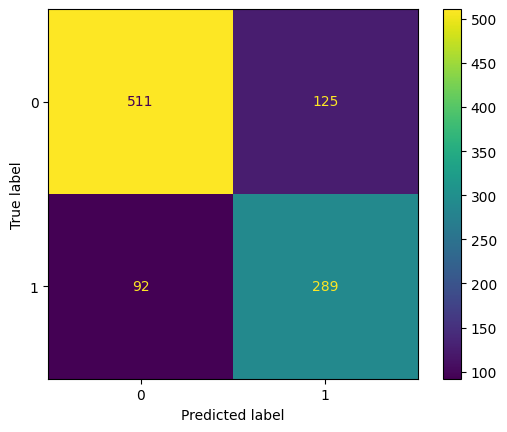

In [132]:
# matrice de confusion ExtraTrees Sans PCA
y_test_predET = finalModelET2.predict(X_testScaledLag)
cm3 = confusion_matrix(y_testScaledLag, y_test_predET)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()

# Explicabilité

## SHAP ExtraTrees (RobustScaler)

In [176]:
# pour un modèle d'arbre avec pca
explainer = shap.TreeExplainer(finalModelET2)
shap_values = explainer.shap_values(X_testScaledLag)
shap_values_pos = shap_values[:,:,1]   # classe positive (conflit)

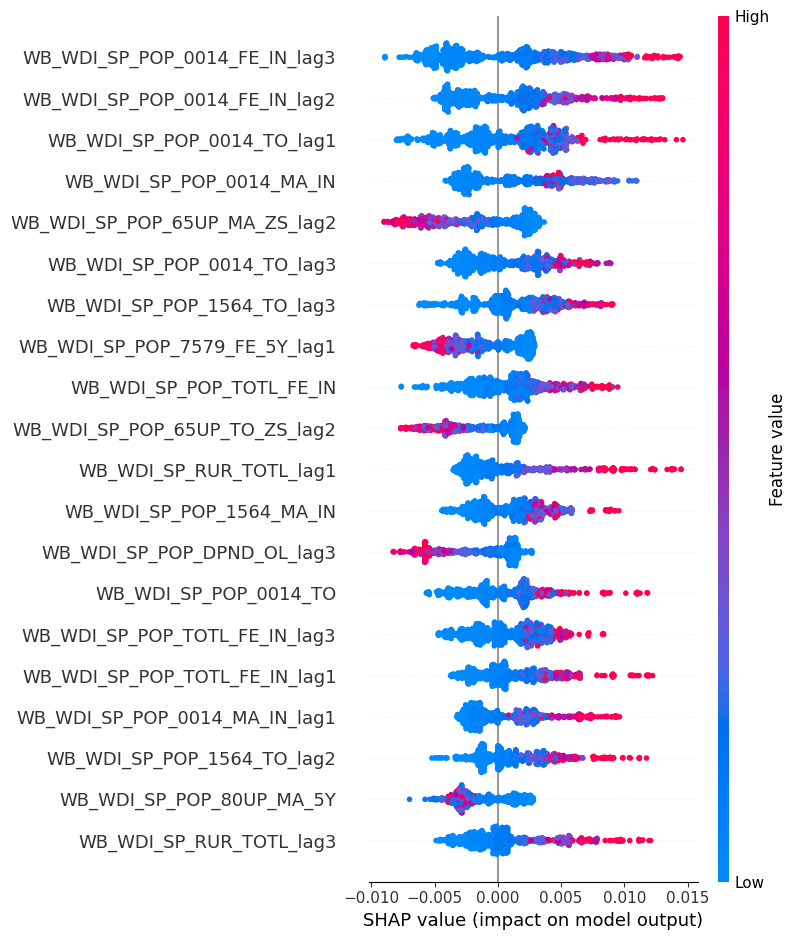

In [177]:

shap.summary_plot(
    shap_values_pos,
    X_testScaledLag,
    feature_names=X_testScaledLag.columns
)

In [181]:
mean_abs_shap = np.mean(np.abs(shap_values_pos), axis=0)
mean_shap_signe = np.mean(shap_values_pos, axis=0)

#d'abord regex pour extraire les nom des features 
def split_feature_name(feature):
    match = re.match(r"(.+?)_(lag1|lag2|lag3|)$", feature)
    if match:
        return match.group(1), match.group(2) # retourne l'id et l'aggregateur
    else:
        return feature, "aucune"

rows = []
# création d'un dataframe récapitulant : l'indicateur, la valeur SHAP et le signe 
for i, feature in enumerate(X_testScaledLag.columns):
    base_id, agg = split_feature_name(feature)

    # label lisible
    label = correspondanceIndicateurs.loc[
        correspondanceIndicateurs["id"] == base_id, "label"
    ]
    label = label.values[0] if not label.empty else base_id

    indicateur_complet = f"{label} ({agg})" if agg != "aucune" else label

    rows.append({
        "Feature_code": feature,
        "Indicateur_complet": indicateur_complet,
        "SHAP": mean_abs_shap[i],
        "Effet": "+" if mean_shap_signe[i] > 0 else "-"
    })

    
df_explain = pd.DataFrame(rows)
df_explain.sort_values(["SHAP"], ascending=False, inplace=True)


In [183]:
df_explain.head(10)

,Feature_code,Indicateur_complet,SHAP,Effet
516,WB_WDI_SP_POP_0014_FE_IN_lag3,"Population ages 0-14, female (lag3)",0.004562,+
350,WB_WDI_SP_POP_0014_FE_IN_lag2,"Population ages 0-14, female (lag2)",0.003409,+
188,WB_WDI_SP_POP_0014_TO_lag1,"Population ages 0-14, total (lag1)",0.003403,+
20,WB_WDI_SP_POP_0014_MA_IN,"Population ages 0-14, male",0.003321,+
391,WB_WDI_SP_POP_65UP_MA_ZS_lag2,"Population ages 65 and above, male (% of male ...",0.003174,-
520,WB_WDI_SP_POP_0014_TO_lag3,"Population ages 0-14, total (lag3)",0.002683,+
532,WB_WDI_SP_POP_1564_TO_lag3,"Population ages 15-64, total (lag3)",0.002681,+
230,WB_WDI_SP_POP_7579_FE_5Y_lag1,"Population ages 75-79, female (% of female pop...",0.002621,-
74,WB_WDI_SP_POP_TOTL_FE_IN,"Population, female",0.002495,+
393,WB_WDI_SP_POP_65UP_TO_ZS_lag2,Population ages 65 and above (% of total popul...,0.002492,-


## Visualisation finale

In [ ]:
# on visualise l'état de conflit dans le monde pour une année aléatoire du dataset de test
# récuperer l'information REF_AREA et TIME_PERIOD avant split x/y en constuisant un index de metadonnées ?

In [134]:

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)




,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,None,None,None,None,None,None,None,None,None,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Admin-0 country,1,3,Yemen,YEM,0,2,Sovereign country,1,Yemen,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Admin-0 country,3,2,Vietnam,VNM,0,2,Sovereign country,1,Vietnam,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Admin-0 country,5,3,Venezuela,VEN,0,2,Sovereign country,1,Venezuela,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


In [136]:

# on créer un dataframe en récuperant les informations pays, année pour stocker les résultats de prédiction
y_test_proba = finalModelET2.predict_proba(X_testScaledLag)[:, 1]
y_test_pred  = finalModelET2.predict(X_testScaledLag)


df_pred_test = test_scaledLag[["REF_AREA", "TIME_PERIOD", "war_nextYear"]].copy()

df_pred_test["proba_conflict"] = y_test_proba
df_pred_test["y_pred"] = y_test_pred

df_pred_test["y_true"] = y_testScaledLag

# on extrait une année pour la visualisation : année 2018 donc on met 2017 pour prédire 2018
df_2018 = df_pred_test[df_pred_test["TIME_PERIOD"] == "2017-01-01"]

In [138]:
# code pour remplacer les code ISO_A3 dans le df qui sont à -99 et mettre la valeur de ADMIN

# créer un dict pour tous les -99
replace_dict = {}

# recupère les lignes avec ISO_A3 = -99
missing_iso = world[world["ISO_A3"] == "-99"]

for idx, row in missing_iso.iterrows():
    admin = row["ADMIN"]
    # transformer le nom du pays en code ISO-3 on peut le faire avec pycountry
    try:
        country = pycountry.countries.lookup(admin)
        replace_dict[idx] = country.alpha_3
    except LookupError:
        replace_dict[idx] = "-99" # sinon on laisse -99

# remplace dans world
for idx, iso in replace_dict.items():
    world.at[idx, "ISO_A3"] = iso

In [139]:
world_pred = world.merge(
    df_2018,
    left_on="ISO_A3",
    right_on="REF_AREA",
    how="left"
)

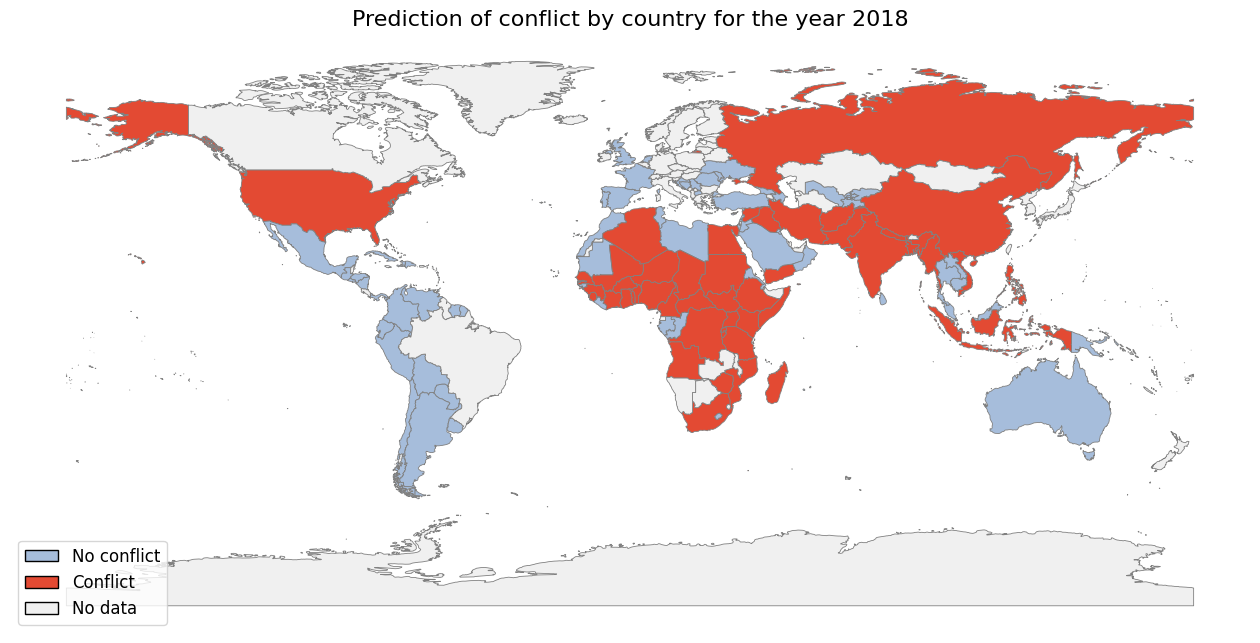

In [151]:
#prédiction
# palette douce
cmap_binary = ListedColormap(["#a6bddb", "#e34a33"])  # bleu clair / rouge foncé

# légende plus jolie
legend_elements = [
    mpatches.Patch(facecolor="#a6bddb", edgecolor="k", label="No conflict"),
    mpatches.Patch(facecolor="#e34a33", edgecolor="k", label="Conflict"),
    mpatches.Patch(facecolor="#f0f0f0", edgecolor="k", label="No data")
]

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

world_pred.plot(
    column="y_pred",
    cmap=cmap_binary,
    linewidth=0.6,
    edgecolor="0.5",
    ax=ax,
    missing_kwds={"color": "#f0f0f0"}  # gris clair pour no data
)

ax.legend(handles=legend_elements, loc="lower left", frameon=True, facecolor="white", fontsize=12)
ax.set_title("Prediction of conflict by country for the year 2018", fontsize=16)
ax.axis("off")

plt.savefig(
    "results/map_prediction_2018.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


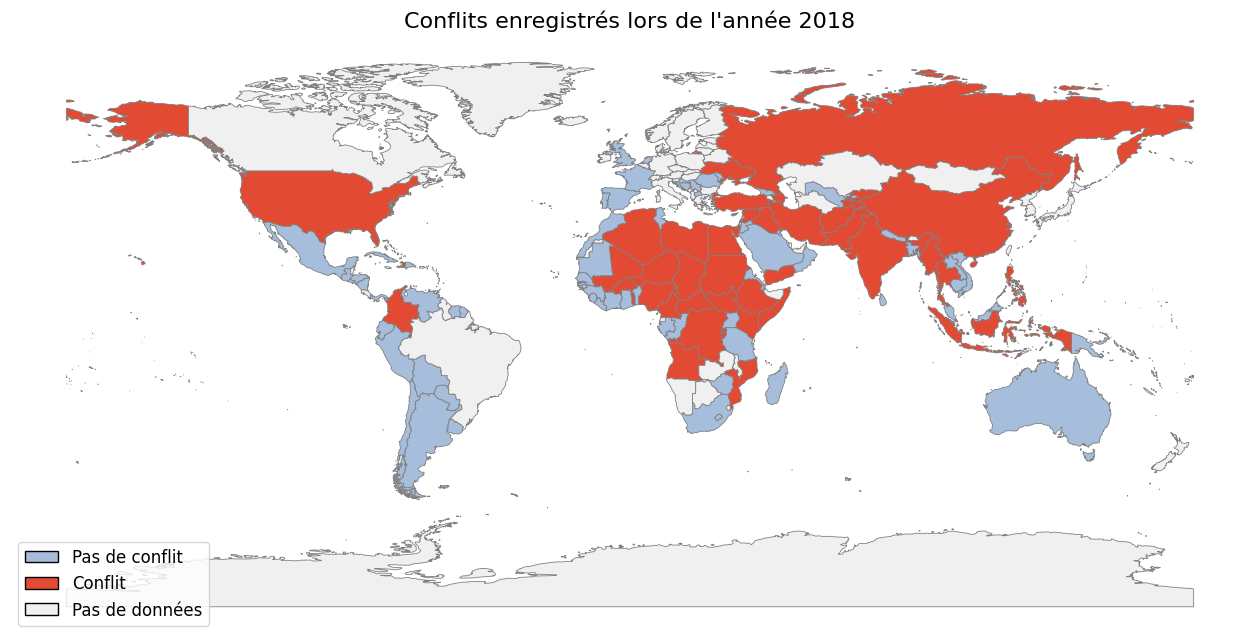

In [93]:
# Grand truth
# palette douce
cmap_binary = ListedColormap(["#a6bddb", "#e34a33"])  # bleu clair / rouge foncé

# légende plus jolie
legend_elements = [
    mpatches.Patch(facecolor="#a6bddb", edgecolor="k", label="No conflict"),
    mpatches.Patch(facecolor="#e34a33", edgecolor="k", label="Conflict"),
    mpatches.Patch(facecolor="#f0f0f0", edgecolor="k", label="No data")
]

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

world_pred.plot(
    column="y_true",
    cmap=cmap_binary,
    linewidth=0.6,
    edgecolor="0.5",
    ax=ax,
    missing_kwds={"color": "#f0f0f0"}  # gris clair pour no data
)

ax.legend(handles=legend_elements, loc="lower left", frameon=True, facecolor="white", fontsize=12)
ax.set_title("Conflits enregistrés lors de l'année 2018", fontsize=16)
ax.axis("off")

plt.show()


In [147]:
# maintenant visualisation des erreurs 

world_pred["error_type"] = "Correct"

world_pred.loc[
    (world_pred["y_pred"] == 1) & (world_pred["y_true"] == 0),
    "error_type"
] = "False Positive"

world_pred.loc[
    (world_pred["y_pred"] == 0) & (world_pred["y_true"] == 1),
    "error_type"
] = "False Negative"

cmap_error = ListedColormap([
    "#d9d9d9",  # Correct
    "#fdae61",  # False Positive
    "#8073ac"   # False Negative
])

# Legend for visualization
legend_elements = [
    mpatches.Patch(facecolor="#d9d9d9", edgecolor="k", label="Correct Prediction"),
    mpatches.Patch(facecolor="#fdae61", edgecolor="k", label="False Positive"),
    mpatches.Patch(facecolor="#8073ac", edgecolor="k", label="False Negative"),
    mpatches.Patch(facecolor="#f0f0f0", edgecolor="k", label="No Data")
]

world_pred["error_type"] = world_pred["error_type"].astype("category")
world_pred["error_type"] = world_pred["error_type"].cat.set_categories(
    ["Correct", "False Positive", "False Negative"]
)




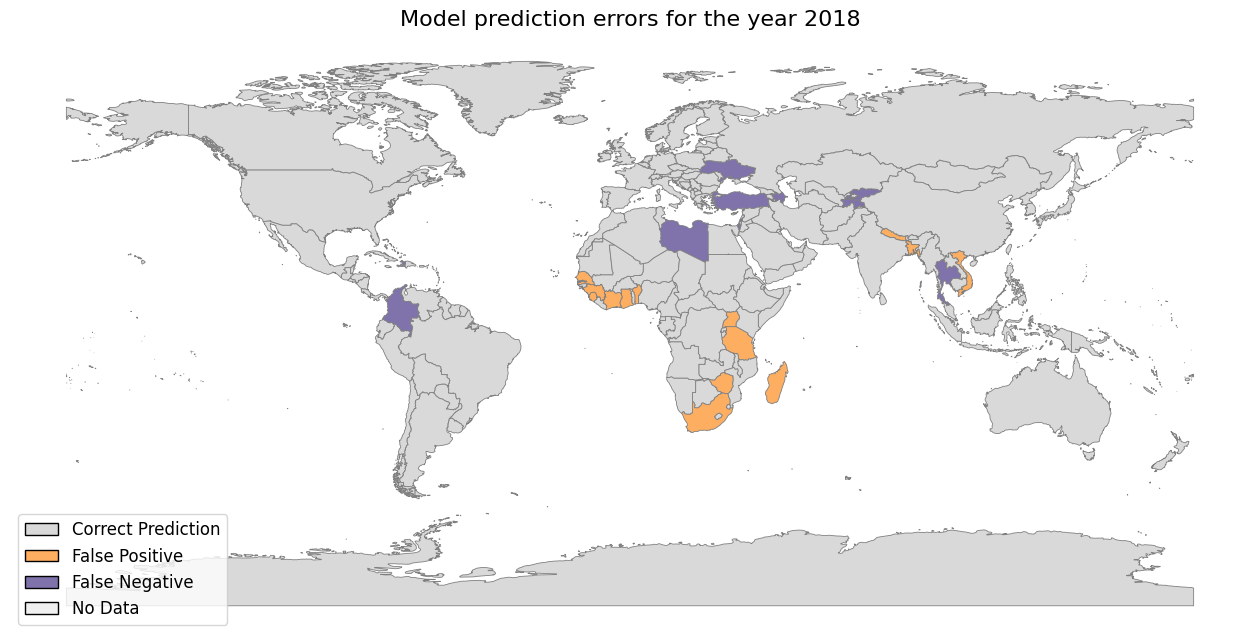

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

world_pred.plot(
    column="error_type",
    cmap=cmap_error,
    linewidth=0.6,
    edgecolor="0.5",
    ax=ax,
    missing_kwds={"color": "#f0f0f0"}
)

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    facecolor="white",
    fontsize=12
)

ax.set_title("Model prediction errors for the year 2018", fontsize=16)
ax.axis("off")
plt.savefig(
    "results/map_erreur_2018.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
